# Quadratic inference Pareto front (3D)

Global bound (GCQP) → GCD refinement → continuation of the quadratic inference problem (Sec. *Quadratic Inference* of `main.tex`) with the original objective added as a constraint:

$$\min_\delta \tilde J_\mathrm{inf}^{(k)}(\delta)\quad \text{s.t.}\quad (\hat I-\hat I_\mathrm{opt})^H L^\star (\hat I-\hat I_\mathrm{opt}) = \varepsilon,\qquad P(\hat I) = P_\mathrm{target},$$

$P_\mathrm{target}$ is swept between the full-plate value and the GCD bound. For each $P_\mathrm{target}$ the continuation starts at the feasible point of minimal Lagrangian distance, $\min (\hat I-\hat I_\mathrm{opt})^H L^\star (\hat I-\hat I_\mathrm{opt})$ s.t. $P(\hat I)=P_\mathrm{target}$, which gives $\varepsilon_\mathrm{min}$ and the first expansion point; $\varepsilon$ is then swept upwards. Each step uses the Hermitian Takagi upper model $H+P$ in $\mathbb{C}^N$ and is solved as a `DenseSharedProjQCQP` with two general constraints and no projector constraints.

In [1]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [2]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [3]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ Vinc)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

def evalObj(Ivec):
    return(-np.real(Ivec.conj().T @ Obj @ Ivec) + 2*np.real(Ivec.conj().T @ obj) + obj0)

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObj(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


In [4]:

Pdiags = np.conj(Zs) * np.ones((Ndes,1), dtype=complex)
Plist = [sp.diags(Pdiags[:,i]) for i in range(Pdiags.shape[1])]

Bmat = Obj
bVec = obj
beta = obj0


Umat = -(Zmat + Z0)/Zs
eVec = -1j * Vinc/2/np.conj(Zs)


QCQP = DenseSharedProjQCQP(
    Bmat, bVec, beta,
    Umat.conj().T, eVec,
    Plist,
    verbose=1,
)

t1 = time.time()
lags_init = np.zeros((Pdiags.shape[1],))
lags_init[0] = -1

# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(opttol=1e-4,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 1 A matrices and Fs vectors.
Optimizer initialized with parameters:
opttol: 0.0001
gradConverge: True
min_inner_iter: 10
max_restart: 10
penalty_ratio: 0.01
penalty_reduction: 0.1
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [-1.]
Outer iteration 0, penalty_ratio = 0.01, opt_fx = 12.229409615164153
iter_num: 5, prev_fx: inf, opt_fx: 12.183203106222196, opttol: 0.0001
iter_num: 10, prev_fx: 12.183203106222196, opt_fx: 12.18320310621814, opttol: 0.0001
Outer iteration 1, penalty_ratio = 0.001, opt_fx = 12.18320310621814
iter_num: 5, prev_fx: 12.183203106222196, opt_fx: 12.18320310621814, opttol: 0.0001
bound: 1.2183e+01, time: 0.04253697395324707s, Lagrange multipliers: [-0.9408364]


In [5]:
# A is the total system matrix. Here I'm checking the minimum eigenvalue to see how PSD it is.
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimum eigenvalue: {np.min(np.real(eigenvals))}")
 

Pdiags = QCQP.Proj.Pdiags


Ivec = QCQP.current_xstar
Popt = evalObj(Ivec) # optimal objective value
print(f"Optimal objective value: {Popt:.6e} W")

minimum eigenvalue: 0.011985437522414438
Optimal objective value: 1.218320e+01 W


In [6]:
from dolphindes.cvxopt.gcd import GCDHyperparameters
import copy
gcd_QCQP = copy.deepcopy(QCQP)

t = time.time()
opt_params = OptimizationHyperparameters(
    opttol=1e-6,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=0              
)

gcd_params = GCDHyperparameters(
    gcd_tol=1e-3,                 # Keep extremely tight to prevent early exit
    max_proj_cstrt_num=30,       # CRITICAL: > 390. Safely covers all complex degrees of freedom!
    max_gcd_iter_num=50,         # Increased to give GCD enough runway to generate up to 400 constraints
    gcd_iter_period=10,            # Check for convergence every 2*Nopt iterations to give GCD enough time to generate constraints and converge
    orthonormalize=True,         # Keep OFF so complex phase information isn't scrambled
    opt_params=opt_params
)
gcd_QCQP.run_gcd(gcd_params=gcd_params)
print(f'gcd optimization took time {time.time()-t}.')

Precomputed 1 A matrices and Fs vectors.
At GCD iteration #1, best dual bound found is             12.183203106226483.
min eigenvalue: 1.198544e-02
At GCD iteration #2, best dual bound found is             12.144430336869478.
min eigenvalue: 1.101319e-02
At GCD iteration #3, best dual bound found is             12.110428083191904.
min eigenvalue: 9.810845e-03
At GCD iteration #4, best dual bound found is             12.087019792841232.
min eigenvalue: 8.802409e-03
At GCD iteration #5, best dual bound found is             12.067520991847251.
min eigenvalue: 8.240366e-03
At GCD iteration #6, best dual bound found is             12.046066045421187.
min eigenvalue: 8.049540e-03
At GCD iteration #7, best dual bound found is             12.011733224868847.
min eigenvalue: 7.129409e-03
At GCD iteration #8, best dual bound found is             11.965480665306524.
min eigenvalue: 5.563271e-03
At GCD iteration #9, best dual bound found is             11.919866245395838.
min eigenvalue: 4.765463e

In [7]:
# Now let's check again for PSD of A. We don't expect the constraints to hold or to have strong duality
lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimal eigenvalue: {np.min(np.real(eigenvals))}")

minimal eigenvalue: 0.06366309382715069


In [8]:
# Now I take the solved gcd_QCQP and finetune it with BFGS if necessary.
t1 = time.time()
gcd_final_result = gcd_QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = gcd_QCQP.current_lags, opt_params = None)
print(f"bound: {gcd_final_result[0]}, time: {time.time()-t1}s")

# Let's check for PSD-ness and constraints again

lags = gcd_QCQP.current_lags
Pdiags = gcd_QCQP.Proj.Pdiags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"min eigenvalue: {np.min(np.real(eigenvals))}")

Ivec= gcd_QCQP.current_xstar

primar_obj = evalObj(Ivec)
print(f"GCD primary objective: {primar_obj}")
print(f"GCD dual bound: {gcd_QCQP.current_dual}")

bound: 10.24745983223072, time: 0.1140589714050293s
min eigenvalue: 0.06366309382288685
GCD primary objective: 10.247459833195515
GCD dual bound: 10.24745983223072


## Quadratic inference model

In [9]:
import matplotlib.pyplot as plt
from scipy.optimize import brentq

Iopt = gcd_QCQP.current_xstar
Lstar = Msym(gcd_QCQP._get_total_A(gcd_QCQP.current_lags))   # quadratic part of the Lagrangian
lamMinL = np.min(np.linalg.eigvalsh(Lstar))
print(f"min eig L*: {lamMinL:.3e}")

Zhat = Ztot   # Zs*I + Z0 in the whitened basis

def residuals(I):
    return Zs*I, Zhat @ I - Vinc          # vacuum residual a, material residual b

def Jinf(I):
    a, b = residuals(I)
    return np.sum(np.abs(a*b.conj())**2)

def inferredDensity(I):
    a, b = residuals(I)
    return a/(a - b)                        # = Zs I / (V - Z0 I)

def taylor(I):
    """g, H, K of the second-order expansion of Jinf at I."""
    a, b = residuals(I)
    q = a*b.conj()
    Da, Db = np.abs(a)**2, np.abs(b)**2
    g = np.conj(Zs)*Db*a + Zhat.conj().T @ (Da*b)
    H = (np.abs(Zs)**2*np.diag(Db) + Zhat.conj().T @ (Da[:, None]*Zhat)
         + Zs*Zhat.conj().T @ np.diag(q.conj()) + np.conj(Zs)*(q[:, None]*Zhat))
    K = 2*Zs*(np.conj(a*b)[:, None]*Zhat)
    return g, Msym(H), 0.5*(K + K.T)

def predicted(I, d):
    g, H, K = taylor(I)
    return Jinf(I) + 2*np.real(g.conj() @ d) + np.real(d.conj() @ H @ d) + np.real(d @ K @ d)

# sanity check of the expansion: error should scale as t^3
rng = np.random.default_rng(0)
dir_ = rng.standard_normal(Ndes) + 1j*rng.standard_normal(Ndes); dir_ *= np.linalg.norm(Iopt)/np.linalg.norm(dir_)
for t in [1e-2, 1e-3, 1e-4]:
    print(f"t={t:.0e}: |J - J~| / J = {abs(Jinf(Iopt + t*dir_) - predicted(Iopt, t*dir_))/Jinf(Iopt):.3e}")

min eig L*: 6.366e-02
t=1e-02: |J - J~| / J = 1.799e-02
t=1e-03: |J - J~| / J = 1.662e-05
t=1e-04: |J - J~| / J = 1.648e-08


## Inference QCQP with objective constraint

In [10]:
import scipy.linalg as sla

def realizedObj(dens):
    S = np.diag(dens.astype(complex))
    I = np.linalg.solve(Zs*np.eye(Ndes) + S @ Z0, S @ Vinc)
    return evalObj(I)

def lagDist(I):
    e = I - Iopt
    return np.real(e.conj() @ Lstar @ e)

import os, warnings
INF_TOL = float(os.environ.get('INF_TOL', '1e-6'))   # dual tolerance of the inference QCQP
Pdual = gcd_QCQP.current_dual

inf_opt = OptimizationHyperparameters(opttol=INF_TOL, gradConverge=True, min_inner_iter=5, max_restart=10,
                                      penalty_ratio=1e-2, penalty_reduction=0.1, break_iter_period=5, verbose=0)

def takagiBound(K):
    """P = (K^H K)^{1/2}, so that |d^T K d| <= d^H P d (Takagi bound)."""
    _, s, Vh = np.linalg.svd(K)
    return Msym(Vh.conj().T @ (s[:, None]*Vh))

def inferenceStep(Ik, eps, Ptarget, lags0=None):
    """min of the Hermitian upper model J0 + 2Re[g^H x] + x^H (H + P) x, x = I - Ik,
    s.t.  (I-Iopt)^H L* (I-Iopt) = eps  and  P(I) = Ptarget,
    posed for y = I - Iopt as a DenseSharedProjQCQP with two general constraints and no projector constraints."""
    g, H, K = taylor(Ik)
    M = Msym(H + takagiBound(K))
    e = Ik - Iopt
    J0 = Jinf(Ik)
    sc = 1/J0                                          # scale the objective to O(1)
    # maximize -J~(y - e)
    A0 = sc*M
    s0 = -sc*(g - M @ e)
    c0 = -sc*(J0 - 2*np.real(g.conj() @ e) + np.real(e.conj() @ M @ e))
    # Lagrangian distance:  -y^H L* y + eps = 0
    B1, s1g, c1 = Lstar/eps, Vzero, 1.0
    # original objective:  -(y+Iopt)^H Obj (y+Iopt) + 2Re[(y+Iopt)^H obj] + obj0 - Ptarget = 0
    B2 = Msym(Obj)/Ptarget
    s2g = (obj - Obj @ Iopt)/Ptarget
    c2 = (evalObj(Iopt) - Ptarget)/Ptarget
    Q = DenseSharedProjQCQP(A0, s0, c0, np.eye(Ndes, dtype=complex), Vzero,
                            [], Pstruct=sp.eye(Ndes),   # no projector constraints
                            B_j=[B1, B2], s_2j=[s1g, s2g], c_2j=[c1, c2], verbose=0)
    if lags0 is None:   # make A0 + mu L*/eps positive definite
        lmin = sla.eigh(A0, B1, eigvals_only=True, subset_by_index=[0, 0])[0]
        lags0 = np.array([max(-lmin, 0)*1.5 + 1.0, 0.0])
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            Q.solve_current_dual_problem(method='newton', init_lags=lags0, opt_params=inf_opt)
    except (ValueError, np.linalg.LinAlgError):
        return Ik, np.inf, None, np.inf               # failed solve -> rejected step
    I = Iopt + Q.current_xstar
    res = max(abs(lagDist(I) - eps)/eps, abs(evalObj(I) - Ptarget)/Ptarget)
    return I, predicted(Ik, I - Ik), Q.current_lags, res

def minEpsPoint(Ptarget):
    """Feasible starting point of the P level set closest to Iopt:
    min (I-Iopt)^H L* (I-Iopt)  s.t.  P(I) = Ptarget,
    a single-constraint QCQP (S-lemma, strong duality) as a DenseSharedProjQCQP."""
    B2 = Msym(Obj)/Ptarget
    s2g = (obj - Obj @ Iopt)/Ptarget
    c2 = (evalObj(Iopt) - Ptarget)/Ptarget
    Q = DenseSharedProjQCQP(Lstar, Vzero, 0.0, np.eye(Ndes, dtype=complex), Vzero,
                            [], Pstruct=sp.eye(Ndes),   # no projector constraints
                            B_j=[B2], s_2j=[s2g], c_2j=[c2], verbose=0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        Q.solve_current_dual_problem(method='newton', init_lags=np.zeros(1), opt_params=inf_opt)
    I = Iopt + Q.current_xstar
    return I, lagDist(I), abs(evalObj(I) - Ptarget)/Ptarget


## 3D Pareto sweep

dual bound 1.024746e+01 W, P(Iopt) 1.024746e+01 W, full plate 1.010821e+01 W
L*-distance of the full plate: 4.068e+01, J_inf(Iopt) = 1.050e+00
sweep: coarse, 3 objective levels, eps growth 3.0, max 20 steps per level


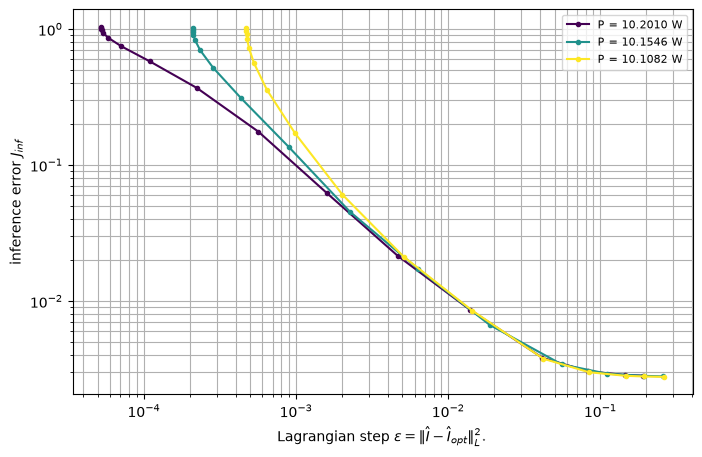

P = 10.20104 W: eps_min 5.203e-05, J_inf 1.038e+00, P residual 6.3e-11
  [  0] eps 5.208e-05 (d 5.20e-08): J_inf 1.021e+00, pred 1.021e+00 (err 5.5e-09), cstr res 2.8e-09, |dI|/|I| 2.5e-05, P(I) 1.02010e+01 W, lags [    8.181 -3594.015], 0.08s -> accepted
  step   1: eps 5.208e-05, J_inf 1.021e+00 (pred 1.021e+00), clipped design 7.9208e-07 W, binary design 0.0000e+00 W | 0 rejected, 0.08s
  [  1] eps 5.224e-05 (d 1.56e-07): J_inf 1.004e+00, pred 1.004e+00 (err 5.5e-09), cstr res 6.1e-08, |dI|/|I| 2.5e-05, P(I) 1.02010e+01 W, lags [    4.12  -1803.244], 0.06s -> accepted
  step   2: eps 5.224e-05, J_inf 1.004e+00 (pred 1.004e+00), clipped design 7.9205e-07 W, binary design 0.0000e+00 W | 0 rejected, 0.14s
  [  2] eps 5.271e-05 (d 4.68e-07): J_inf 9.777e-01, pred 9.777e-01 (err 2.3e-08), cstr res 5.7e-08, |dI|/|I| 4.0e-05, P(I) 1.02010e+01 W, lags [   2.298 -995.595], 0.06s -> accepted
  step   3: eps 5.271e-05, J_inf 9.777e-01 (pred 9.777e-01), clipped design 7.9199e-07 W, binary desig

In [11]:
epsFull = lagDist(Ifull)
print(f"dual bound {Pdual:.6e} W, P(Iopt) {evalObj(Iopt):.6e} W, full plate {Pfull:.6e} W")
print(f"L*-distance of the full plate: {epsFull:.3e}, J_inf(Iopt) = {Jinf(Iopt):.3e}")

import os
# sampling presets, selected by the environment variable SWEEP (coarse | fine)
SWEEP = os.environ.get('SWEEP', 'coarse')
nP, epsGrow, maxSteps = {'coarse': (3, 3.0, 20), 'fine': (20, 1.25, 400)}[SWEEP]
print(f"sweep: {SWEEP}, {nP} objective levels, eps growth {epsGrow}, max {maxSteps} steps per level")
Ptargets = np.linspace(Pdual, Pfull, nP + 1)[1:]       # from the bound downwards; P = Pdual only admits eps -> 0
epsMax = 1.2*epsFull
stepTol, predTol = 0.05, 0.1
Jtol = 1e-8*Jinf(Iopt)     # stopping threshold on the inference error

from IPython.display import display

# live figure: inference error vs Lagrangian step, one colour per objective level
liveFig, liveAx = plt.subplots(figsize=(8, 5))
liveAx.set_xscale('log'); liveAx.set_yscale('log')
liveAx.set_xlabel(r'Lagrangian step $\varepsilon = \|\hat I-\hat I_{opt}\|^2_{L^\star}$')
liveAx.set_ylabel(r'inference error $J_{inf}$')
liveAx.grid(True, which='both')
liveColors = plt.cm.viridis(np.linspace(0, 1, nP))
liveHandle = display(liveFig, display_id=True)
plt.close(liveFig)

def liveUpdate(line, pts):
    line.set_data([p[0] for p in pts], [p[1] for p in pts])
    liveAx.relim(); liveAx.autoscale_view()
    if liveHandle is not None:      # None outside Jupyter (batch runs)
        liveHandle.update(liveFig)

def sweepEps(Ptarget, color=None):
    # start on the P level set at the point of minimal Lagrangian distance; it is the
    # expansion point of the first Taylor model and eps_min is the smallest feasible eps
    Ik, epsk, res0 = minEpsPoint(Ptarget)
    d = np.real(inferredDensity(Ik))
    pts = [(epsk, Jinf(Ik), realizedObj(np.clip(d, 0, 1)), realizedObj((d > 0.5).astype(float)), Ik)]
    print(f"P = {Ptarget:.5f} W: eps_min {epsk:.3e}, J_inf {pts[0][1]:.3e}, P residual {res0:.1e}", flush=True)
    line, = liveAx.plot([], [], 'o-', ms=3, color=color, label=f'P = {Ptarget:.4f} W')
    liveAx.legend(fontsize=8); liveUpdate(line, pts)
    lags, dEps = None, 1e-3*epsk
    nRej, nRejTot, tStep, tLevel = 0, 0, time.time(), time.time()
    for it in range(maxSteps):
        if epsk >= epsMax or dEps < 1e-12*epsMax or pts[-1][1] < Jtol: break
        epsTry = min(epsk + dEps, epsMax)
        # the eps constraint is scaled as L*/eps, so the warm-start multiplier scales with eps
        lagsTry = None if lags is None else lags*np.array([epsTry/epsk, 1.0])
        tTry = time.time()
        I, Jpr, lagsNew, res = inferenceStep(Ik, epsTry, Ptarget, lagsTry)
        Jex = Jinf(I)
        relStep = np.linalg.norm(I - Ik)/np.linalg.norm(Ik)
        predErr = abs(Jex - Jpr)/abs(Jex)
        ok = res < 1e-4 and relStep < stepTol and predErr <= predTol
        lagStr = "None" if lagsNew is None else np.array2string(np.asarray(lagsNew), precision=3)
        print(f"  [{it:3d}] eps {epsTry:.3e} (d {dEps:.2e}): J_inf {Jex:.3e}, pred {Jpr:.3e} (err {predErr:.1e}), "
              f"cstr res {res:.1e}, |dI|/|I| {relStep:.1e}, P(I) {evalObj(I):.5e} W, lags {lagStr}, "
              f"{time.time()-tTry:.2f}s -> {'accepted' if ok else 'rejected'}", flush=True)
        if ok:
            Ik, epsk, lags = I, epsTry, lagsNew
            d = np.real(inferredDensity(I))
            pts.append((epsk, Jex, realizedObj(np.clip(d, 0, 1)), realizedObj((d > 0.5).astype(float)), I))
            print(f"  step {len(pts)-1:3d}: eps {epsk:.3e}, J_inf {Jex:.3e} (pred {Jpr:.3e}), "
                  f"clipped design {pts[-1][2]:.4e} W, binary design {pts[-1][3]:.4e} W | "
                  f"{nRej} rejected, {time.time()-tStep:.2f}s", flush=True)
            nRej, tStep = 0, time.time()
            liveUpdate(line, pts)
            dEps *= epsGrow
        else:
            dEps *= 0.5; lags = None
            nRej += 1; nRejTot += 1
    print(f"  level done: {len(pts)-1} accepted, {nRejTot} rejected, {time.time()-tLevel:.1f}s", flush=True)
    return pts

t1 = time.time()
front = {}
for i, P in enumerate(Ptargets):
    front[P] = sweepEps(P, liveColors[i])
    e = front[P][-1] if front[P] else None
    print(f"P = {P:.5f} W: {len(front[P])} points" + (f", eps_end {e[0]:.3e}, J_inf {e[1]:.3e}, binary {e[3]:.4e} W" if e else ""))
    if e and e[1] < Jtol:
        print(f"inference error below {Jtol:.1e}: realizable current found, stopping the sweeps")
        break
print(f"time {time.time()-t1:.1f}s")

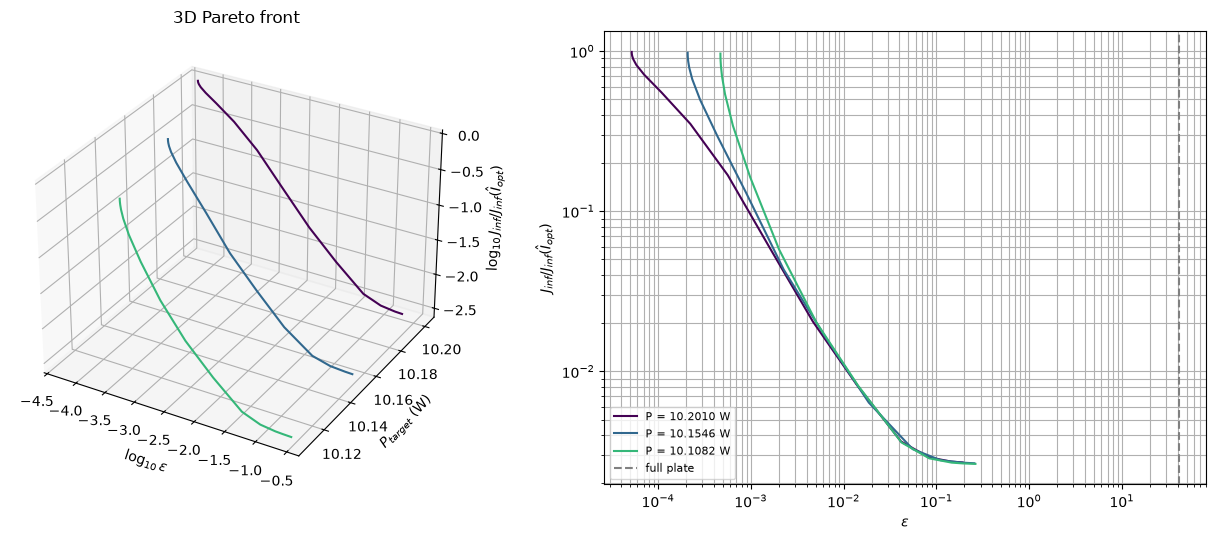

In [12]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(13, 5.5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
cmap = plt.cm.viridis
for i, (P, pts) in enumerate(front.items()):
    if not pts: continue
    e = np.array([p[0] for p in pts]); J = np.array([p[1] for p in pts])
    ax.plot(np.log10(e), P*np.ones_like(e), np.log10(J/Jinf(Iopt)), '-', color=cmap(i/len(front)))
ax.set_xlabel(r'$\log_{10}\varepsilon$'); ax.set_ylabel(r'$P_{target}$ (W)'); ax.set_zlabel(r'$\log_{10} J_{inf}/J_{inf}(\hat I_{opt})$')
ax.set_title('3D Pareto front')
ax2 = fig.add_subplot(1, 2, 2)
for i, (P, pts) in enumerate(front.items()):
    if not pts: continue
    e = np.array([p[0] for p in pts]); J = np.array([p[1] for p in pts])
    ax2.loglog(e, J/Jinf(Iopt), '-', color=cmap(i/len(front)), label=f'P = {P:.4f} W')
ax2.axvline(epsFull, ls='--', c='gray', label='full plate')
ax2.set_xlabel(r'$\varepsilon$'); ax2.set_ylabel(r'$J_{inf}/J_{inf}(\hat I_{opt})$'); ax2.grid(True, which='both'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

best binary design: 0.000000e+00 W at P_target 10.20104 W, eps 1.919e-01 (full plate 1.010821e+01 W)


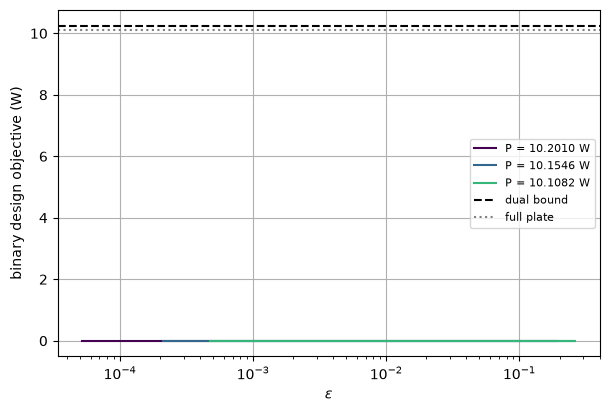

In [13]:
# realized objective of the binary (> 0.5) inferred designs along the front
best = max(((p[3], P, p[0]) for P, pts in front.items() for p in pts), default=(np.nan, np.nan, np.nan))
print(f"best binary design: {best[0]:.6e} W at P_target {best[1]:.5f} W, eps {best[2]:.3e} (full plate {Pfull:.6e} W)")
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (P, pts) in enumerate(front.items()):
    if not pts: continue
    ax.semilogx([p[0] for p in pts], [p[3] for p in pts], '-', color=cmap(i/len(front)), label=f'P = {P:.4f} W')
ax.axhline(Pdual, ls='--', c='k', label='dual bound'); ax.axhline(Pfull, ls=':', c='gray', label='full plate')
ax.set_xlabel(r'$\varepsilon$'); ax.set_ylabel('binary design objective (W)'); ax.grid(True); ax.legend(fontsize=8)
plt.show()

In [14]:
# save the front: rows (P_target, eps, J_inf, P_clipped, P_binary)
rows = [(P, p[0], p[1], p[2], p[3]) for P, pts in front.items() for p in pts]
np.savetxt(f'quadratic_inference_front_{SWEEP}.txt', np.array(rows), delimiter=',',
           header='P_target,eps,J_inf,P_clipped,P_binary')